# iADP: continuous learning through an unknown plant change

This complete example uses `IADPAgent`, `IADPConfig.paper` and `ControlBenchmark`
from the installed `tensoraerospace` package. Run the cells in order from any
working directory. All plant transitions, learning calls and plots are visible.

The plant is the exact discretization of `x_dot = -2*x + effectiveness*u`; its
input effectiveness falls from 1 to 0.7 at 60 s. This simple plant lets us compare
the identified gain with an exact value. It is not an aircraft flight-test model.

## 1. Configure identification and the adaptive controller

The first 20 s use multisine excitation. `IADPConfig.paper` selects a full 20 s
critic window and 20 Hz critic fits at a 1 kHz control rate. A small periodic
excitation continues afterward. RLS and the unregularized critic stay active;
there is no event-time reset, blending or PSD projection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensoraerospace.agent.iadp import IADPAgent, IADPConfig
from tensoraerospace.benchmark import ControlBenchmark

plt.rcParams.update(
    {
        "figure.dpi": 125,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
dt, duration = 0.001, 80.0
time = np.arange(round(duration / dt) + 1) * dt
identification_time = np.arange(round(20.0 / dt)) * dt
excitation = (
    0.15 * np.sin(2 * np.pi * 0.7 * identification_time)
    + 0.05 * np.sin(2 * np.pi * 1.7 * identification_time)
)[:, None]
period = np.arange(round(10.0 / dt)) * dt
ongoing_excitation = (0.015 * np.sin(2 * np.pi * 0.7 * period))[:, None]
config = IADPConfig.paper(
    excitation_signal=excitation,
    dt=dt,
    learning_mode="continuous",
    Q=np.array([[100.0]]),
    R=np.array([[0.0001]]),
    gamma=0.95,
    gamma_rls=0.999,
    phi_init=1e6,
    u_magnitude_limit=0.5,
    u_rate_limit=2.0,
    continuous_excitation_signal=ongoing_excitation,
)
agent = IADPAgent(1, 1, config)
x = np.zeros(1)
reference = np.array([0.05])
a = np.exp(-2 * dt)
b = (1 - a) / 2


## 2. Apply control and learn each measured transition

`predict` requests a command. The plant advances once, then `learn` receives
that new state and the actual applied command. The controller never receives
the effectiveness or event time. `states` includes the initial sample; every
control and gain estimate belongs to one completed transition.

In [2]:
states, actions, estimated_gain, true_gain = [x[0]], [], [], []
for k, t in enumerate(time[:-1]):
    command = agent.predict(x, reference, k)
    # The unknown effectiveness change belongs to the plant only.
    effectiveness = 1.0 if t < 60.0 else 0.7
    x = a * x + b * effectiveness * command
    agent.learn(x, reference, k, applied_action=command)
    if not np.isfinite(x).all() or not np.isfinite(agent.P).all():
        raise FloatingPointError(f"Nonfinite state or critic at {time[k+1]:g} s")
    states.append(x[0])
    actions.append(command[0])
    estimated_gain.append(agent.G[0, 0])
    true_gain.append(b * effectiveness)
states, actions, estimated_gain, true_gain = map(
    np.asarray, (states, actions, estimated_gain, true_gain)
)
assert len(actions) == len(time) - 1
assert agent.rls.num_updates == len(actions) - 1
print(f"Completed {time[-1]:g} s; RLS updates: {agent.rls.num_updates}")


Completed 80 s; RLS updates: 79999


## 3. Evaluate tracking with the library benchmark

The observation windows are (40, 60] s and (65, 80] s. They exclude the initial
identification phase and, for the second metric, the first 5 s after the fault.
The smaller later error is not evidence that damage improves the plant.

In [3]:
benchmark = ControlBenchmark()
nominal = benchmark.tracking_metrics(0.05, states, dt, start=40.0, end=60.0)
faulty = benchmark.tracking_metrics(0.05, states, dt, start=65.0, end=80.0)
print("Nominal RMSE [rad/s]:", nominal["combined_rmse"])
print("Post-fault RMSE [rad/s]:", faulty["combined_rmse"])
print("Identified / true final G:", estimated_gain[-1], true_gain[-1])
print("Final minimum critic eigenvalue:", np.linalg.eigvalsh(agent.P).min())


Nominal RMSE [rad/s]: 2.7621172603519763e-05
Post-fault RMSE [rad/s]: 1.1528108911163642e-05
Identified / true final G: 0.000699300466138281 0.0006993004664333835
Final minimum critic eigenvalue: 0.007974606614766344


## 4. Plot the reference, actual control and identified gain

The shaded region is the initial identification phase. The fault line and true
gain are evaluation annotations only. A good gain estimate on this scalar model
does not establish stability or parameter convergence on a nonlinear aircraft.

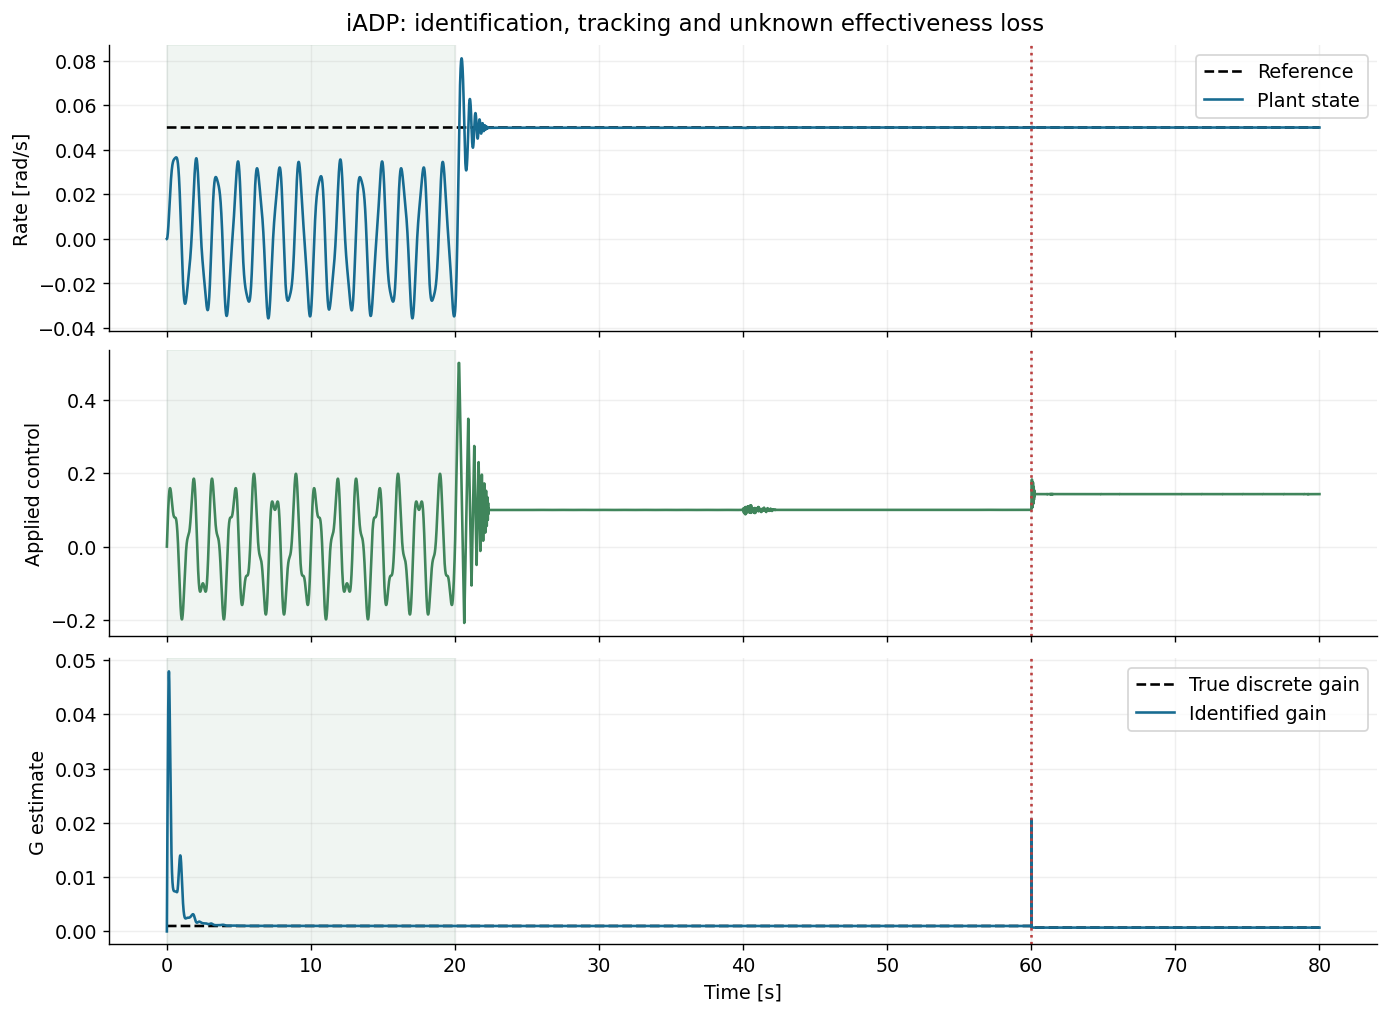

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
axes[0].plot(time, np.full_like(time, reference[0]), "k--", label="Reference")
axes[0].plot(time, states, color="#176b91", label="Plant state")
axes[0].set_ylabel("Rate [rad/s]")
axes[0].legend()
axes[1].plot(time[1:], actions, color="#40855b")
axes[1].set_ylabel("Applied control")
axes[2].plot(time[1:], true_gain, "k--", label="True discrete gain")
axes[2].plot(time[1:], estimated_gain, color="#176b91", label="Identified gain")
axes[2].set_ylabel("G estimate")
axes[2].legend()
for ax in axes:
    ax.axvspan(0, 20, alpha=0.08, color="#40855b")
    ax.axvline(60, color="#bb4040", linestyle=":")
axes[-1].set_xlabel("Time [s]")
fig.suptitle("iADP: identification, tracking and unknown effectiveness loss")
plt.show()


## Continue with an aircraft

- [Nonlinear B737 pitch step](example_iadp_nonlinear_b737.ipynb): native SDK environment, nominal initialization and pitch/rate cascade.
- [B737 elevator-effectiveness loss](example_iadp_fault_b737.ipynb): continuous adaptation and post-fault metrics.
- [F-16 long-horizon diagnostic](example_iadp_small_fault_f16.ipynb): inspect actual completion and failure status.